# DL082 可运行实验：逆问题与科学数据
先合成真值，后真实NIST观测。公开源文件已保存，本Notebook默认离线运行。

验证规模：完整测试套件13项；Notebook共8个代码单元。局部演示可先跑子集，最后一格执行全部13项。

In [1]:
import numpy as np,json,hashlib
from pathlib import Path
import experiment as ex
print("NumPy",np.__version__)
print(json.loads(Path("data/provenance.json").read_text()))

NumPy 2.3.5
{'dataset': 'NIST StRD Misra1a', 'kind': 'observed real experimental data', 'source_url': 'https://www.itl.nist.gov/div898/strd/nls/data/LINKS/DATA/Misra1a.dat', 'landing_url': 'https://www.itl.nist.gov/div898/strd/nls/data/misra1a.shtml', 'access_date': '2026-10-10', 'bytes': 1932, 'sha256': '9d3194d537d9a6bbf92eb819504070923a1885d0191f40b6b3aaeedd130b98e2', 'rows': 14, 'raw_column_order': ['volume', 'pressure'], 'units': 'source file names volume and pressure but does not specify measurement units', 'license_url': 'https://www.nist.gov/open/license', 'changes': 'raw downloaded bytes unchanged; analysis scales pressure /1000 and volume /100 in memory'}


## 1 读取真实数据并承认单位缺口
源文件列顺序为y,x，函数返回pressure,volume。具体单位名称未知，不能擅自标为SI。

In [2]:
p,v=ex.read_real()
print("观测数",len(p),"压力范围",p.min(),p.max())
print(np.column_stack([p,v])[:4])

观测数 14 压力范围 77.6 760.0
[[ 77.6   10.07]
 [114.9   14.73]
 [141.1   17.94]
 [190.8   23.93]]


## 2 不可辨识的代数检查
增益与幅度同时未知，只有乘积被观测。

In [3]:
x=np.linspace(0,5,101)
print("两组参数最大差",np.max(np.abs(ex.forward(x,2.4,.55)-2*ex.forward(x,1.2,.55))))

两组参数最大差 0.0


## 3 无噪声恢复与数值校验
这不是现实参数真值，只是检查已知生成模型的算法。

In [4]:
truth=np.array([2.4,.55]); x=np.linspace(.01,5,24)
theta,sse=ex.fit(x,ex.forward(x,*truth))
print("恢复",theta,"SSE",sse)
assert np.allclose(theta,truth,rtol=1e-7)

恢复 [2.4  0.55] SSE 7.247903317226632e-30


## 4 完整重复噪声、正则与真实验证
每个设计200次，真实条件自助法300次。全部实际执行，不使用预先硬编码的指标。

In [5]:
metrics=ex.run()
print(json.dumps(metrics,ensure_ascii=False,indent=2))

{
  "seed": 82,
  "synthetic_truth": [
    2.4,
    0.55
  ],
  "noise_sigma": 0.01,
  "replicates": 200,
  "synthetic": {
    "narrow": {
      "median": [
        1.4918758622559447,
        0.9510029281061487
      ],
      "q025": [
        0.08663314833398256,
        0.00010000000002070934
      ],
      "q975": [
        14165.122867275042,
        21.31756932855764
      ],
      "relative_parameter_rmse": [
        3760.290489189801,
        13.225752779728316
      ],
      "sensitivity_condition": 734.9400908101544,
      "range": [
        0.005,
        0.05
      ],
      "b_search_boundary_fraction": 0.475,
      "regularized_correct_prior": {
        "median": [
          2.399952933622468,
          0.552613503782164
        ],
        "q025": [
          2.3978661196446103,
          0.5004506183027602
        ],
        "q975": [
          2.4022007946408537,
          0.6101252222038952
        ],
        "relative_parameter_rmse": [
          0.0004333667299761471,

## 5 参数恢复与搜索边界
窄设计的极端值及边界碰撞是结果的一部分，不能悄悄删除。

In [6]:
for design,m in metrics["synthetic"].items():
    print(design,"条件数",m["sensitivity_condition"],"A分位数",m["q025"][0],m["q975"][0],"边界比例",m["b_search_boundary_fraction"])

narrow 条件数 734.9400908101544 A分位数 0.08663314833398256 14165.122867275042 边界比例 0.475
medium 条件数 42.223347350890315 A分位数 2.0758035985509116 2.943370659488497 边界比例 0.0
wide 条件数 7.221912196403836 A分位数 2.385741342901542 2.41450901726393 边界比例 0.0


## 6 留出与全数据拟合区分
高4点只用于预设评价，最终全数据参数另行报告。

In [7]:
r=metrics["real"]
print("保留集：饱和/直线RMSE",r["heldout_saturation_rmse"],r["heldout_linear_rmse"])
print("全数据参数",r["full_fit_parameters_original_units"])
print("条件区间",r["conditional_parametric_bootstrap_95pct"])
print("守恒",r["conservation"])

保留集：饱和/直线RMSE 0.5551703082113263 3.8733997455521
全数据参数 [238.94212983229104, 0.0005501564300496555]
条件区间 [[234.15493586194214, 0.0005357185501196986], [244.41088239198078, 0.0005633461048528205]]
守恒 not applicable: static adsorption response, no mass-flow/time information


## 7 画图并运行测试
自助法样本不是新增真实观测。

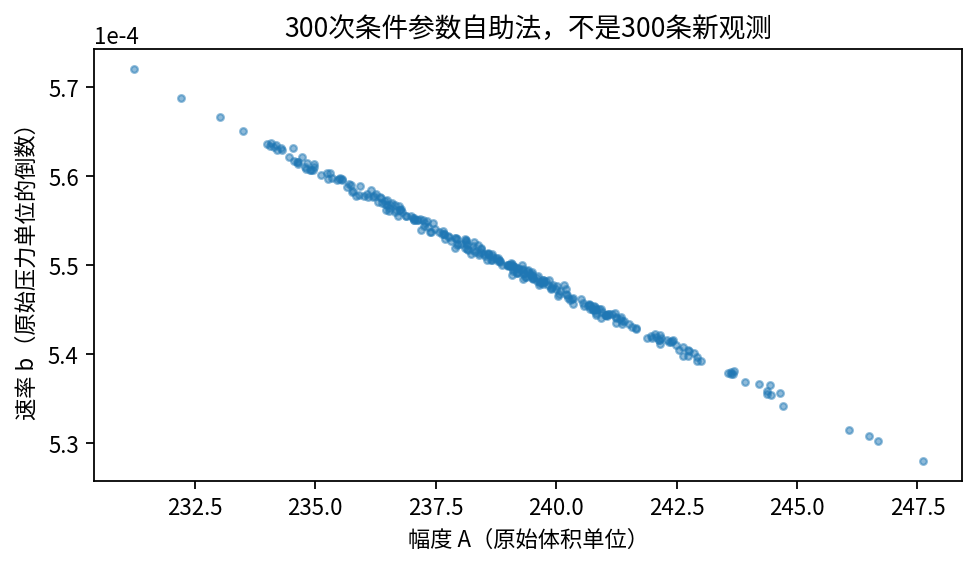

test_invalid_dimensions (test_experiment.RobustnessTests.test_invalid_dimensions) ... 

ok


test_invalid_observations (test_experiment.RobustnessTests.test_invalid_observations) ... 

ok


test_invalid_regularization (test_experiment.RobustnessTests.test_invalid_regularization) ... 

...

test_source_integrity (test_experiment.Tests.test_source_integrity) ... 

ok


test_split_and_results (test_experiment.Tests.test_split_and_results) ... 

ok


----------------------------------------------------------------------
Ran 13 tests in 0.027s

OK


In [8]:
import runpy,unittest,test_experiment
runpy.run_path("make_figures.py",run_name="__main__")
from IPython.display import Image,display
display(Image(filename="figures/05_bootstrap.png"))
result=unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
assert result.wasSuccessful()

## 8 你的研究结论
请分别写出：计算认证、参数辨识、现实模型验证、领域结论。至少给出一个当前数据无法回答的问题。